In [1]:
import os

os.environ["KAGGLE_USERNAME"] = "your_username"
os.environ["KAGGLE_KEY"] = "KGAT_124923f5129871b94d6c636d1b8bdba2"

In [ ]:
import os
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

# Authenticate (requires kaggle.json in ~/.kaggle or credentials in env vars)
api = KaggleApi()
api.authenticate()

# Download and unzip the dataset
api.dataset_download_files(
    "kritikseth/fruit-and-vegetable-image-recognition",
    path="data",
    unzip=True
)

In [1]:
import cv2
import tensorflow as tf
import os
import pathlib
import glob
#initialize classes of fruits and vegs
classes = {"fruits": ["Banana", "Apple", "Pear", "Grapes", "Orange", "Kiwi", "Watermelon", "Pomegranate",
           "Pineapple", "Mango"], "vegetables": ["Cucumber", "Carrot", "Capsicum", "Onion", "Potato", "Lemon",
           "Tomato", "Raddish", "Beetroot", "Cabbage", "Lettuce", "Spinach", "Soy beans",
           "Cauliflower", "Bell Pepper", "Chilli Pepper", "Turnip", "Corn", "Sweetcorn",
           "SweetPotato", "Paprika", "Jalepeno", "Ginger", "Garlic", "Peas", "Eggplant"]}

# classes = [i.lower() for i in classes]
#process images
def get_data(classes, folder):
  data = []
  labels = []
  for i,value in classes.items():
      for j in value:
          path = os.path.join("data", folder, j.lower())
          for img in os.listdir(path):
            img_array = cv2.imread(os.path.join(path, img))
            img_resized = cv2.resize(img_array, (100, 100))
            img_array = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
            img_array = img_resized / 255.0
            #Store processed image
            data.append(img_array)
            #store labels
            labels.append(i)

  return data, labels

data, labels = get_data(classes, "train")


In [ ]:
# labels

In [2]:
import numpy as np
#train the model
x = np.array(data)
y = np.array(labels)
print(x.shape)
print(y.shape)


(3115, 100, 100, 3)
(3115,)


'fruits'

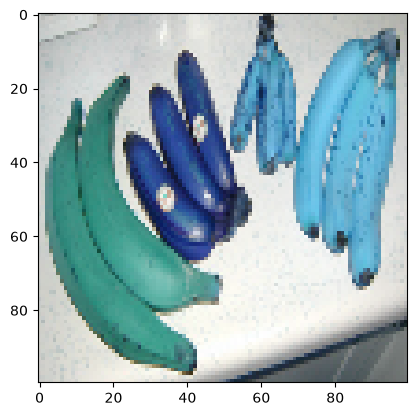

In [3]:
import matplotlib.pyplot as plt
plt.imshow(x[3])
labels[3]

In [4]:
y

array(['fruits', 'fruits', 'fruits', ..., 'vegetables', 'vegetables',
       'vegetables'], shape=(3115,), dtype='<U10')

In [5]:
#encode y
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
y = np.where(y == "fruits", 1, 0) #fruits => 1, vegetables => 0
y

array([1, 1, 1, ..., 0, 0, 0], shape=(3115,))

In [6]:
#build odel
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

model = Sequential([
    layers.Conv2D(128, (3,3), padding="same", activation="relu", input_shape=(100,100,3)),
    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dropout(0.2),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

C:\Users\testi\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#compile the model
model.compile(optimizer = "adam", loss="binary_crossentropy", metrics=["accuracy"])

In [8]:
X_val, y_val = get_data(classes, "validation")

X_val = np.array(X_val)
y_val = np.array(y_val)

y_val = np.where(y_val == "fruits", 1, 0)


model.fit(x, y, epochs=10, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.7262 - loss: 0.6023 - val_accuracy: 0.7236 - val_loss: 0.6183
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7307 - loss: 0.5611 - val_accuracy: 0.7265 - val_loss: 0.5639
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7307 - loss: 0.5488 - val_accuracy: 0.7721 - val_loss: 0.5338
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.7406 - loss: 0.5294 - val_accuracy: 0.7521 - val_loss: 0.5013
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.7457 - loss: 0.5159 - val_accuracy: 0.7949 - val_loss: 0.4793
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7637 - loss: 0.4904 - val_accuracy: 0.7949 - val_loss: 0.4251
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 79s 808ms/step - accuracy: 0.7682 - loss: 0.4800 - val_accuracy: 0.8462 - val_loss: 0.3846
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7942 - loss: 0.4420 - val_accuracy: 0.8547 -

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 100, 100, 128)       │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 100, 100, 64)        │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 50, 50, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 50, 50, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 50, 50, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 25, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 20000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,560,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,020,613 (30.60 MB)

 Trainable params: 2,673,537 (10.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,347,076 (20.40 MB)

In [10]:
loss,accuracy = model.evaluate(x, y)
print("Loss:", loss)
print("Accuracy:", accuracy)

98/98 ━━━━━━━━━━━━━━━━━━━━ 45s 459ms/step - accuracy: 0.8738 - loss: 0.3093
Loss: 0.30930617451667786
Accuracy: 0.8738362789154053


In [11]:
x_test, y_test = get_data(classes, "test")
x_test = np.array(x_test)
y_test = np.where(np.array(y_test) == "fruits", 1, 0)

loss, acc = model.evaluate(x_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 332ms/step - accuracy: 0.9220 - loss: 0.2538
Test Loss: 0.25378912687301636
Test Accuracy: 0.9220055937767029


In [13]:
#Checking test images 
test_images = [
    "data/test/apple/Image_1.jpg",
    "data/test/banana/Image_1.jpg",
    "data/test/cucumber/Image_1.jpg",
    "data/test/potato/Image_1.jpg"
]

for path in test_images:
    img = cv2.imread(path)
    img = cv2.resize(img, (100, 100))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prob = model.predict(img, verbose=0)[0][0]

    print(path)
    print("Probability:", prob)
    print("Prediction:", "Fruit" if prob >= 0.5 else "Vegetable")
    print("-" * 40)

data/test/apple/Image_1.jpg
Probability: 0.9964163
Prediction: Fruit
----------------------------------------
data/test/banana/Image_1.jpg
Probability: 0.28936714
Prediction: Vegetable
----------------------------------------
data/test/cucumber/Image_1.jpg
Probability: 0.005588624
Prediction: Vegetable
----------------------------------------
data/test/potato/Image_1.jpg
Probability: 0.96094316
Prediction: Fruit
----------------------------------------


In [14]:
#Checking unseen images 
test_images = [
    "data/check/apple.jpg",
    "data/check/radish.jpg",
    "data/check/garlic.jpg",
    "data/check/potato.jpg"
]

for path in test_images:
    img = cv2.imread(path)
    img = cv2.resize(img, (100, 100))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prob = model.predict(img, verbose=0)[0][0]

    print(path)
    print("Probability:", prob)
    print("Prediction:", "Fruit" if prob >= 0.5 else "Vegetable")
    print("-" * 40)

data/check/apple.jpg
Probability: 0.9135465
Prediction: Fruit
----------------------------------------
data/check/radish.jpg
Probability: 0.004955876
Prediction: Vegetable
----------------------------------------
data/check/garlic.jpg
Probability: 0.07092392
Prediction: Vegetable
----------------------------------------
data/check/potato.jpg
Probability: 0.29981682
Prediction: Vegetable
----------------------------------------


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(x_test, verbose=0)
y_pred = (y_pred >= 0.5).astype(int).flatten()

print(confusion_matrix(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=["vegetables", "fruits"]   # 0 then 1
))

[[245  15]
 [ 13  86]]
              precision    recall  f1-score   support

  vegetables       0.95      0.94      0.95       260
      fruits       0.85      0.87      0.86        99

    accuracy                           0.92       359
   macro avg       0.90      0.91      0.90       359
weighted avg       0.92      0.92      0.92       359

